# Reinforcement Learning — The Framework

## What is Reinforcement Learning?

Reinforcement Learning (RL) is a type of machine learning where an **agent** learns to make decisions by **interacting with an environment** and receiving **rewards or penalties** for its actions.

### The Core Idea
- An agent takes **actions**
- The environment returns a new **state** and a **reward**
- The agent **learns** to maximise cumulative reward over time

```
         ┌──────────────────────────────────┐
         │            ENVIRONMENT           │
         │  state(t+1), reward(t+1)         │
         └──────────┬───────────────────────┘
                    │ observation / reward
                    ▼
         ┌──────────────────────────────────┐
         │             AGENT                │
         │  policy π(a|s)                   │
         └──────────┬───────────────────────┘
                    │ action(t)
                    ▼
         ┌──────────────────────────────────┐
         │            ENVIRONMENT           │
         └──────────────────────────────────┘
```

---

In [1]:
# ============================================================
# CELL 1: Install and import libraries
# ============================================================
# Run this first
# !pip install numpy matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Libraries loaded')

Libraries loaded


## 1. The RL Loop — Step by Step

The fundamental RL interaction loop:
1. Agent observes state **s(t)**
2. Agent selects action **a(t)** using its policy
3. Environment transitions to **s(t+1)** and returns **r(t+1)**
4. Agent updates its knowledge
5. Repeat until terminal state or max steps

Let's build the simplest possible RL loop from scratch:

In [2]:
# ============================================================
# CELL 2: Build the RL Loop from scratch — Corridor World
# ============================================================
# Environment: A 1D corridor with 5 positions
# Agent: starts at position 0, goal is position 4
# Actions: 0 = move left, 1 = move right
# Reward: +10 at goal, -1 each step (to encourage efficiency)

class CorridorEnvironment:
    """Simple 1D corridor: [0] [1] [2] [3] [4*]"""

    def __init__(self, length=5):
        self.length = length
        self.goal = length - 1
        self.state = None

    def reset(self):
        """Reset agent to start position."""
        self.state = 0
        return self.state

    def step(self, action):
        """Take action: 0=left, 1=right"""
        if action == 0:  # move left
            self.state = max(0, self.state - 1)
        elif action == 1:  # move right
            self.state = min(self.length - 1, self.state + 1)

        # Calculate reward
        if self.state == self.goal:
            reward = +10
            done = True
        else:
            reward = -1   # step penalty
            done = False

        return self.state, reward, done


class RandomAgent:
    """Agent that picks actions randomly (baseline)."""

    def __init__(self, n_actions=2):
        self.n_actions = n_actions

    def select_action(self, state):
        return np.random.choice(self.n_actions)


# ---- Run ONE episode ----
env = CorridorEnvironment(length=5)
agent = RandomAgent(n_actions=2)

state = env.reset()
total_reward = 0
trajectory = [state]
step_count = 0

print('🚶 RL Loop — One Episode (Random Agent)')
print(f'  Initial State: {state}')
print('-' * 45)

for t in range(20):  # max 20 steps
    action = agent.select_action(state)
    next_state, reward, done = env.step(action)

    action_name = 'RIGHT →' if action == 1 else 'LEFT ←'
    print(f'  Step {t+1:2d}: s={state} | a={action_name} | s_new={next_state} | r={reward:+d}')

    total_reward += reward
    trajectory.append(next_state)
    state = next_state
    step_count += 1

    if done:
        print(f'\n  🎯 Goal reached in {step_count} steps!')
        break

print(f'\n  Total Reward: {total_reward}')
print(f'  Trajectory: {trajectory}')

🚶 RL Loop — One Episode (Random Agent)
  Initial State: 0
---------------------------------------------
  Step  1: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step  2: s=0 | a=RIGHT → | s_new=1 | r=-1
  Step  3: s=1 | a=RIGHT → | s_new=2 | r=-1
  Step  4: s=2 | a=LEFT ← | s_new=1 | r=-1
  Step  5: s=1 | a=LEFT ← | s_new=0 | r=-1
  Step  6: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step  7: s=0 | a=RIGHT → | s_new=1 | r=-1
  Step  8: s=1 | a=LEFT ← | s_new=0 | r=-1
  Step  9: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step 10: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step 11: s=0 | a=RIGHT → | s_new=1 | r=-1
  Step 12: s=1 | a=LEFT ← | s_new=0 | r=-1
  Step 13: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step 14: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step 15: s=0 | a=RIGHT → | s_new=1 | r=-1
  Step 16: s=1 | a=LEFT ← | s_new=0 | r=-1
  Step 17: s=0 | a=LEFT ← | s_new=0 | r=-1
  Step 18: s=0 | a=RIGHT → | s_new=1 | r=-1
  Step 19: s=1 | a=LEFT ← | s_new=0 | r=-1
  Step 20: s=0 | a=RIGHT → | s_new=1 | r=-1

  Total Reward: -20
  Trajec

## 2. Key RL Terms Visualised

| Term | Symbol | Meaning |
|------|--------|---------|
| **State** | s | Current situation of the environment |
| **Action** | a | Decision the agent makes |
| **Reward** | r | Feedback signal from environment |
| **Policy** | π(a\|s) | Agent's strategy: what action to take in each state |
| **Episode** | — | One complete interaction from start to terminal |
| **Return** | G | Cumulative (discounted) reward from time t |
| **Discount** | γ (gamma) | How much future rewards are valued (0–1) |

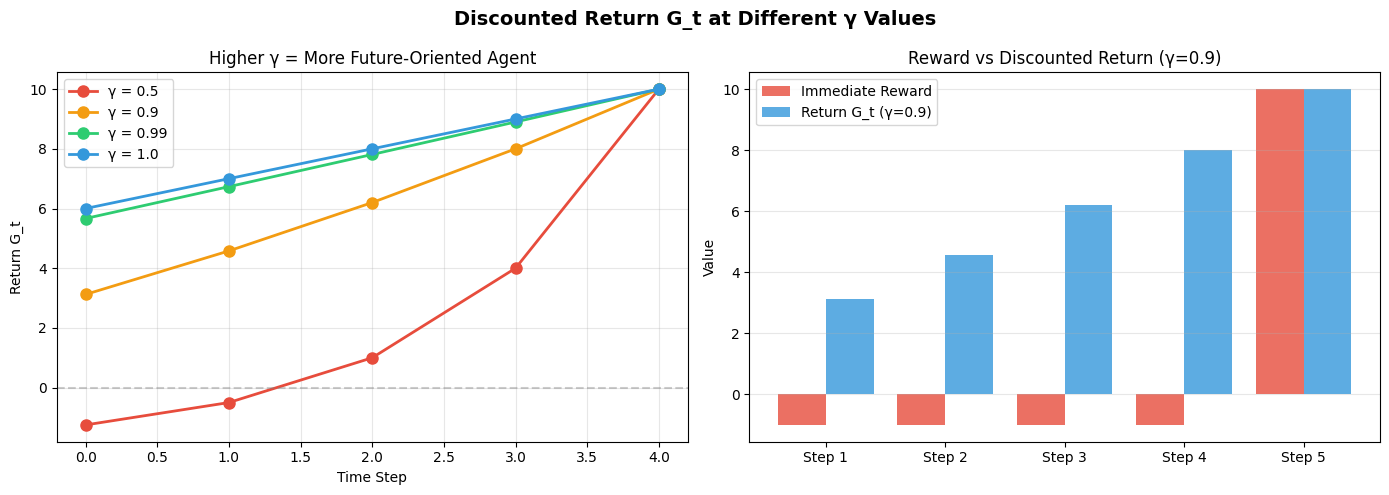


💡 Key Insight: With γ < 1, a reward at step 5 is worth less than the same
   reward at step 1. This encourages the agent to reach goals faster.


In [3]:
# ============================================================
# CELL 3: Visualise Return (Discounted Cumulative Reward)
# ============================================================
# Return G_t = r_{t+1} + γ·r_{t+2} + γ²·r_{t+3} + ...

def compute_return(rewards, gamma=0.9):
    """Compute discounted return from a list of rewards."""
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

# Example reward sequence
rewards = [-1, -1, -1, -1, +10]
gammas  = [0.5, 0.9, 0.99, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discounted Return G_t at Different γ Values', fontsize=14, fontweight='bold')

# Left: Show return for each gamma
ax = axes[0]
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
steps = range(len(rewards))

for gamma, color in zip(gammas, colors):
    G_vals = compute_return(rewards, gamma)
    ax.plot(steps, G_vals, 'o-', color=color, linewidth=2,
            label=f'γ = {gamma}', markersize=8)

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Time Step')
ax.set_ylabel('Return G_t')
ax.set_title('Higher γ = More Future-Oriented Agent')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Reward vs Return bar chart
ax2 = axes[1]
G_vals_90 = compute_return(rewards, gamma=0.9)
x = np.arange(len(rewards))
ax2.bar(x - 0.2, rewards, 0.4, label='Immediate Reward', color='#e74c3c', alpha=0.8)
ax2.bar(x + 0.2, G_vals_90, 0.4, label='Return G_t (γ=0.9)', color='#3498db', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Step {i+1}' for i in x])
ax2.set_ylabel('Value')
ax2.set_title('Reward vs Discounted Return (γ=0.9)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('\nKey Insight: With γ < 1, a reward at step 5 is worth less than the same')
print('   reward at step 1. This encourages the agent to reach goals faster.')

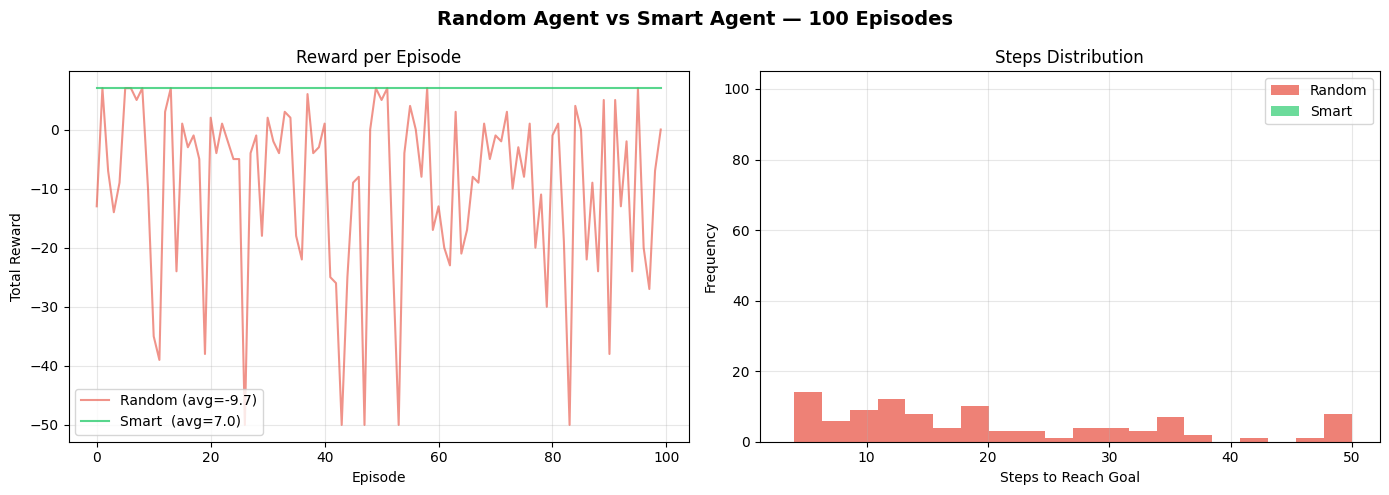

In [4]:
# ============================================================
# CELL 4: Compare Random vs Always-Right Policy over 100 Episodes
# ============================================================

def run_episodes(env, agent, n_episodes=100, max_steps=50):
    rewards_per_episode = []
    steps_per_episode = []

    for ep in range(n_episodes):
        state = env.reset()
        total_r = 0
        for t in range(max_steps):
            action = agent.select_action(state)
            state, reward, done = env.step(action)
            total_r += reward
            if done:
                steps_per_episode.append(t + 1)
                break
        else:
            steps_per_episode.append(max_steps)
        rewards_per_episode.append(total_r)

    return rewards_per_episode, steps_per_episode


class SmartAgent:
    """Agent that always goes RIGHT (optimal for corridor world)."""
    def select_action(self, state):
        return 1  # always right


np.random.seed(42)
env = CorridorEnvironment(length=5)

random_rewards, random_steps = run_episodes(env, RandomAgent(), 100)
smart_rewards, smart_steps   = run_episodes(env, SmartAgent(), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Agent vs Smart Agent — 100 Episodes', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(random_rewards, alpha=0.6, color='#e74c3c', label=f'Random (avg={np.mean(random_rewards):.1f})')
ax.plot(smart_rewards,  alpha=0.8, color='#2ecc71', label=f'Smart  (avg={np.mean(smart_rewards):.1f})')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Reward per Episode')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(random_steps, bins=20, alpha=0.7, color='#e74c3c', label='Random')
ax2.hist(smart_steps,  bins=20, alpha=0.7, color='#2ecc71', label='Smart')
ax2.set_xlabel('Steps to Reach Goal')
ax2.set_ylabel('Frequency')
ax2.set_title('Steps Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. RL vs Supervised vs Unsupervised Learning

| Feature | Supervised | Unsupervised | Reinforcement |
|---------|-----------|--------------|---------------|
| **Training Data** | Labelled (X, y) | Unlabelled X | Interactions with env |
| **Feedback** | Explicit correct answer | None | Delayed reward signal |
| **Goal** | Predict output | Find patterns | Maximise cumulative reward |
| **Key Challenge** | Generalisation | Clustering quality | Exploration vs exploitation |
| **Example** | Email spam filter | Customer segmentation | Game playing, robotics |

---
### Summary
- RL has **no labelled dataset** — the agent generates its own experience
- The reward signal can be **sparse** and **delayed** (hard problem!)
- The agent must **explore** to learn, but also **exploit** what it already knows
- This tension is called the **Exploration–Exploitation Trade-off**